### Giới thiệu Dự án Phân tích Dữ liệu Thị trường Chứng khoán

Trong dự án này, chúng ta sẽ khám phá và phân tích bộ dữ liệu lịch sử giá cổ phiếu từ các chỉ số chứng khoán hàng đầu như NYSE Composite (NYA) và các chỉ số khác.

**Mục tiêu của dự án:**
- Hiểu rõ cấu trúc và đặc điểm của dữ liệu thị trường chứng khoán.
- Áp dụng các kỹ thuật tiền xử lý dữ liệu để làm sạch và chuẩn bị dữ liệu cho phân tích.
- Tạo ra các đặc trưng mới (feature engineering) để hỗ trợ phân tích sâu hơn.
- Trực quan hóa dữ liệu để phát hiện xu hướng, phân phối và mối quan hệ giữa các biến.
- Phát triển kỹ năng phân tích dữ liệu thực tế với Python và các thư viện phổ biến như Pandas, NumPy, Seaborn, Matplotlib và Plotly.

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Bước 1: Tải dữ liệu vào DataFrame
# Chúng ta sẽ đọc file CSV có tên 'Market.csv' vào một đối tượng DataFrame của Pandas.
market_df = pd.read_csv('/Users/hungthanh/Documents/Market/Market.csv')

# Hiển thị 5 dòng đầu tiên của DataFrame để xem dữ liệu trông như thế nào.
print("5 dòng đầu tiên của dữ liệu:")
display(market_df.head())

5 dòng đầu tiên của dữ liệu:


,Index,Date,Open,High,Low,Close,Adj Close,Volume
0,NYA,12/31/1965,528.690002,528.690002,528.690002,528.690002,528.690002,0.0
1,NYA,01/03/1966,527.210022,527.210022,527.210022,527.210022,527.210022,0.0
2,NYA,01/04/1966,527.840027,527.840027,527.840027,527.840027,527.840027,0.0
3,NYA,01/05/1966,531.119995,531.119995,531.119995,531.119995,531.119995,0.0
4,NYA,01/06/1966,532.070007,532.070007,532.070007,532.070007,532.070007,0.0


### Bước 2: Khám phá Dữ liệu ban đầu (Initial Data Exploration)

Sau khi tải dữ liệu, điều quan trọng là phải hiểu cấu trúc, kiểu dữ liệu và xem có bất kỳ vấn đề nào như thiếu giá trị hay không. Điều này giúp chúng ta biết được dữ liệu 'kể' câu chuyện gì và cần được 'dọn dẹp' như thế nào.

In [13]:
# Kiểm tra thông tin chung về DataFrame: 
print("Thông tin tổng quan về DataFrame:")
market_df.info()

# Kiểm tra số lượng giá trị thiếu (NaN) trong mỗi cột.
print("\nSố lượng giá trị thiếu trong từng cột:")
print(market_df.isnull().sum())

# Kiểm tra phần trăm giá trị thiếu trong mỗi cột để xem mức độ ảnh hưởng.
print("\nPhần trăm giá trị thiếu trong từng cột:")
print(market_df.isnull().sum() / len(market_df) * 100)

# Hiển thị thống kê mô tả cho các cột số (như giá trị trung bình, độ lệch chuẩn, min, max, các tứ phân vị).
print("\nThống kê mô tả cho các cột số:")
display(market_df.describe())

Thông tin tổng quan về DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 112457 entries, 0 to 112456
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Index      112457 non-null  str    
 1   Date       112457 non-null  str    
 2   Open       110253 non-null  float64
 3   High       110252 non-null  float64
 4   Low        110251 non-null  float64
 5   Close      110250 non-null  float64
 6   Adj Close  110244 non-null  float64
 7   Volume     110253 non-null  float64
dtypes: float64(6), str(2)
memory usage: 6.9 MB

Số lượng giá trị thiếu trong từng cột:
Index           0
Date            0
Open         2204
High         2205
Low          2206
Close        2207
Adj Close    2213
Volume       2204
dtype: int64

Phần trăm giá trị thiếu trong từng cột:
Index        0.000000
Date         0.000000
Open         1.959860
High         1.960749
Low          1.961639
Close        1.962528
Adj Close    1.967863
Volume       1.95

,Open,High,Low,Close,Adj Close,Volume
count,110253.000000,110252.000000,110251.000000,110250.000000,110244.000000,1.102530e+05
mean,7658.561932,7704.538416,7608.129749,7657.740822,7657.982529,1.273975e+09
std,9011.455529,9066.605458,8954.536718,9011.555549,9011.723572,4.315783e+09
min,54.869999,54.869999,54.869999,54.869999,54.869999,0.000000e+00
25%,1855.060059,1864.687470,1844.015015,1855.347473,1855.057556,0.000000e+00
50%,5194.399902,5226.750000,5154.299805,5194.889892,5195.699951,4.329000e+05
75%,10134.299810,10207.827635,10060.369630,10134.867430,10135.512452,1.734314e+08
max,68775.062500,69403.750000,68516.992190,68775.062500,68775.062500,9.440374e+10


In [14]:
## Bước 3: Tiền xử lý dữ liệu - Xử lý giá trị thiếu và chuyển đổi kiểu dữ liệu

# Chuyển đổi cột 'Date' sang định dạng datetime
# errors='coerce' sẽ chuyển đổi các giá trị không hợp lệ thành NaT (Not a Time)
market_df['Date'] = pd.to_datetime(market_df['Date'], errors='coerce')

# Kiểm tra lại các giá trị NaT sau khi chuyển đổi nếu có
print("Số lượng giá trị NaT trong cột Date sau chuyển đổi:")
print(market_df['Date'].isnull().sum())

# Xóa các hàng có giá trị thiếu (NaN) trong các cột 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'
# Vì tỷ lệ giá trị thiếu tương đối nhỏ (khoảng 1.9%), việc xóa bỏ các hàng này có thể là một phương pháp hợp lý để giữ tính toàn vẹn của dữ liệu.
initial_rows = len(market_df)
market_df.dropna(subset=['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], inplace=True)
rows_after_dropping = len(market_df)

print(f"\nSố hàng ban đầu: {initial_rows}")
print(f"Số hàng sau khi xóa giá trị thiếu: {rows_after_dropping}")
print(f"Số hàng đã bị xóa: {initial_rows - rows_after_dropping}")

# Kiểm tra lại thông tin DataFrame sau khi xử lý để đảm bảo không còn giá trị thiếu trong các cột đã chọn
print("\nThông tin tổng quan về DataFrame sau khi xử lý giá trị thiếu:")
market_df.info()

print("\nSố lượng giá trị thiếu trong từng cột sau khi xử lý:")
print(market_df.isnull().sum())

Số lượng giá trị NaT trong cột Date sau chuyển đổi:
0

Số hàng ban đầu: 112457
Số hàng sau khi xóa giá trị thiếu: 110238
Số hàng đã bị xóa: 2219

Thông tin tổng quan về DataFrame sau khi xử lý giá trị thiếu:
<class 'pandas.DataFrame'>
Index: 110238 entries, 0 to 112456
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Index      110238 non-null  str           
 1   Date       110238 non-null  datetime64[us]
 2   Open       110238 non-null  float64       
 3   High       110238 non-null  float64       
 4   Low        110238 non-null  float64       
 5   Close      110238 non-null  float64       
 6   Adj Close  110238 non-null  float64       
 7   Volume     110238 non-null  float64       
dtypes: datetime64[us](1), float64(6), str(1)
memory usage: 7.6 MB

Số lượng giá trị thiếu trong từng cột sau khi xử lý:
Index        0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Clo

### Bước 4: Kỹ thuật Đặc trưng (Feature Engineering)

Trong bước này, chúng ta sẽ tạo các đặc trưng mới từ các cột hiện có để làm phong phú thêm bộ dữ liệu. Điều này có thể giúp khám phá các mẫu hình tiềm ẩn và cải thiện hiệu suất của các mô hình phân tích sau này.

In [15]:
# Trích xuất các đặc trưng thời gian từ cột 'Date'
market_df['Year'] = market_df['Date'].dt.year
market_df['Month'] = market_df['Date'].dt.month
market_df['Day'] = market_df['Date'].dt.day
market_df['DayOfWeek'] = market_df['Date'].dt.dayofweek # Monday=0, Sunday=6

# Tính toán thay đổi giá hàng ngày (Daily Price Change)
# Đây là sự khác biệt giữa giá đóng cửa hiện tại và giá đóng cửa ngày hôm trước.
# Chúng ta cần nhóm theo 'Index' để đảm bảo tính toán sự thay đổi trong cùng một mã chứng khoán.
market_df['Daily_Change'] = market_df.groupby('Index')['Close'].diff()

# Tính toán lợi suất hàng ngày (Daily Return)
# Lợi suất hàng ngày thường được tính bằng (Close hiện tại - Close hôm trước) / Close hôm trước
market_df['Daily_Return'] = market_df.groupby('Index')['Close'].pct_change() * 100 # % change

# Hiển thị 5 dòng đầu tiên với các cột mới
print("5 dòng đầu tiên của dữ liệu sau khi thêm các đặc trưng mới:")
display(market_df.head())

5 dòng đầu tiên của dữ liệu sau khi thêm các đặc trưng mới:


,Index,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,DayOfWeek,Daily_Change,Daily_Return
0,NYA,1965-12-31,528.690002,528.690002,528.690002,528.690002,528.690002,0.0,1965,12,31,4,NaN,NaN
1,NYA,1966-01-03,527.210022,527.210022,527.210022,527.210022,527.210022,0.0,1966,1,3,0,-1.479980,-0.279933
2,NYA,1966-01-04,527.840027,527.840027,527.840027,527.840027,527.840027,0.0,1966,1,4,1,0.630005,0.119498
3,NYA,1966-01-05,531.119995,531.119995,531.119995,531.119995,531.119995,0.0,1966,1,5,2,3.279968,0.621394
4,NYA,1966-01-06,532.070007,532.070007,532.070007,532.070007,532.070007,0.0,1966,1,6,3,0.950012,0.178870


### Bước 5: Trực quan hóa dữ liệu (Data Visualization)

Sau khi tiền xử lý và tạo các đặc trưng mới, chúng ta sẽ trực quan hóa dữ liệu để hiểu rõ hơn về các xu hướng, phân phối và mối quan hệ giữa các biến. Điều này giúp chúng ta có cái nhìn trực quan về 'câu chuyện' mà dữ liệu đang kể.

In [16]:
# Để trực quan hóa, trước tiên chúng ta cần xác định xem có bao nhiêu mã chứng khoán (Index) trong dữ liệu.
# Nếu có nhiều, chúng ta sẽ chọn một vài mã phổ biến hoặc một mã cụ thể để biểu diễn ban đầu.
num_unique_indices = market_df['Index'].nunique()
print(f"Số lượng mã chứng khoán (Index) duy nhất: {num_unique_indices}")

if num_unique_indices > 1:
    print("Các mã chứng khoán hàng đầu:")
    print(market_df['Index'].value_counts().head())
    # Lấy một mã chứng khoán để ví dụ, ví dụ 'NYA' (NYSE Composite)
    selected_index = 'NYA'
    print(f"\nTrực quan hóa giá đóng cửa cho mã chứng khoán: {selected_index}")
    df_selected_index = market_df[market_df['Index'] == selected_index]
else:
    df_selected_index = market_df
    selected_index = market_df['Index'].iloc[0]
    print(f"\nChỉ có một mã chứng khoán: {selected_index}. Trực quan hóa giá đóng cửa cho mã này.")

# Biểu đồ đường của giá đóng cửa theo thời gian cho mã chứng khoán được chọn
fig = px.line(
    df_selected_index,
    x='Date',
    y='Close',
    title=f'Giá Đóng Cửa của {selected_index} theo Thời Gian',
    labels={'Date': 'Ngày', 'Close': 'Giá Đóng Cửa'},
    line_shape='linear'
)
fig.update_xaxes(rangeslider_visible=True)
fig.show()

Số lượng mã chứng khoán (Index) duy nhất: 14
Các mã chứng khoán hàng đầu:
Index
NYA       13932
N225      13874
IXIC      12690
GSPTSE    10526
HSI        8492
Name: count, dtype: int64

Trực quan hóa giá đóng cửa cho mã chứng khoán: NYA


In [17]:
import plotly.express as px

# Ensure 'selected_index' and 'df_selected_index' are defined
# This assumes 'market_df' is already defined from previous steps.
# Based on the previous execution (cell 3cc27736), 'selected_index' was 'NYA'.
selected_index = 'NYA' # Re-assign the selected index based on previous step
df_selected_index = market_df[market_df['Index'] == selected_index]

# Tạo biểu đồ phân phối (histogram) cho 'Daily_Return'
fig = px.histogram(
    df_selected_index,
    x='Daily_Return',
    nbins=50, # Số lượng bins có thể điều chỉnh để xem chi tiết hơn
    title=f'Phân Phối Lợi Suất Hàng Ngày của {selected_index}',
    labels={'Daily_Return': 'Lợi Suất Hàng Ngày (%)'},
    marginal='box' # Thêm biểu đồ hộp để xem phân vị
)
fig.update_layout(bargap=0.1) # Khoảng cách giữa các cột biểu đồ
fig.show()


### Bước 6: Phân tích Tương quan và Thống kê Cơ bản

Sau khi trực quan hóa dữ liệu, chúng ta sẽ tiến hành phân tích tương quan để hiểu mối quan hệ giữa các biến số. Điều này giúp chúng ta phát hiện các biến có ảnh hưởng lẫn nhau như thế nào, ví dụ giữa giá đóng cửa và khối lượng giao dịch.

**Khái niệm cơ bản cho Junior DA:**
- **Tương quan (Correlation):** Đo lường mức độ mối quan hệ tuyến tính giữa hai biến. Giá trị từ -1 đến 1, nơi 1 là tương quan hoàn hảo dương, -1 là âm, và 0 là không tương quan.
- **Ma trận tương quan:** Bảng hiển thị tương quan giữa tất cả các cặp biến số.

Chúng ta sẽ tính toán ma trận tương quan cho các cột số trong dữ liệu của mã chứng khoán đã chọn.

### Bước 7: Kết luận và Bước Tiếp Theo

Chúng ta đã hoàn thành các bước cơ bản của phân tích dữ liệu: từ tải dữ liệu, khám phá, tiền xử lý, tạo đặc trưng, trực quan hóa và phân tích tương quan.

**Những gì chúng ta đã học:**
- Cách làm việc với dữ liệu thời gian trong Pandas.
- Xử lý giá trị thiếu và chuyển đổi kiểu dữ liệu.
- Tạo đặc trưng mới từ dữ liệu hiện có.
- Trực quan hóa dữ liệu với Plotly và Seaborn.
- Phân tích tương quan để hiểu mối quan hệ giữa biến.

**Đối với Junior DA, bước tiếp theo có thể là:**
- Thử nghiệm với các mã chứng khoán khác trong dữ liệu.
- Áp dụng các kỹ thuật thống kê nâng cao như kiểm định giả thuyết.
- Xây dựng mô hình dự đoán giá cổ phiếu đơn giản (ví dụ: hồi quy tuyến tính).
- Học cách xuất dữ liệu đã xử lý ra file CSV để sử dụng ở nơi khác.

Hãy thử chạy lại notebook với một mã chứng khoán khác hoặc thêm phân tích của riêng bạn!

Ma trận tương quan cho NYA:


,Open,High,Low,Close,Adj Close,Volume,Daily_Change,Daily_Return
Open,1.000000,0.999777,0.999880,0.999854,0.999789,0.801041,0.014720,0.000441
High,0.999777,1.000000,0.999783,0.999820,0.999755,0.803276,0.019349,0.003888
Low,0.999880,0.999783,1.000000,0.999957,0.999892,0.797942,0.021376,0.005219
Close,0.999854,0.999820,0.999957,1.000000,0.999935,0.800686,0.025634,0.008568
Adj Close,0.999789,0.999755,0.999892,0.999935,1.000000,0.800642,0.025635,0.008587
Volume,0.801041,0.803276,0.797942,0.800686,0.800642,1.000000,-0.012368,-0.013831
Daily_Change,0.014720,0.019349,0.021376,0.025634,0.025635,-0.012368,1.000000,0.810163
Daily_Return,0.000441,0.003888,0.005219,0.008568,0.008587,-0.013831,0.810163,1.000000


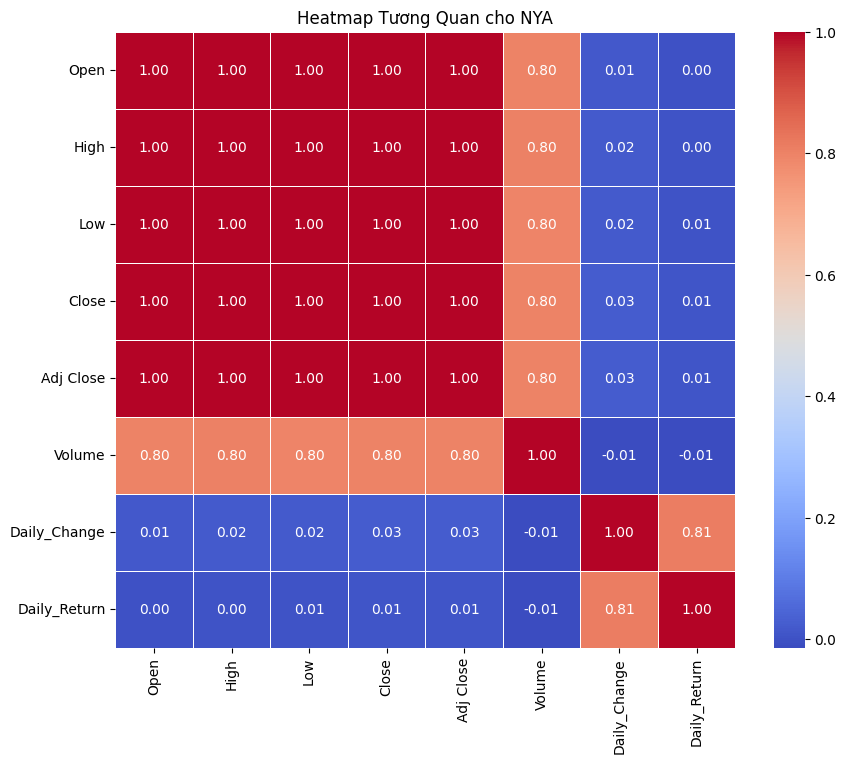


Các cặp biến có tương quan cao nhất:
Low    Close        0.999957
Close  Adj Close    0.999935
Low    Adj Close    0.999892
Open   Low          0.999880
       Close        0.999854
dtype: float64


In [18]:
# Tính toán ma trận tương quan cho các cột số của mã chứng khoán đã chọn
# Chọn chỉ các cột số để tính tương quan
numeric_columns = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Daily_Change', 'Daily_Return']
correlation_matrix = df_selected_index[numeric_columns].corr()

# Hiển thị ma trận tương quan
print(f"Ma trận tương quan cho {selected_index}:")
display(correlation_matrix)

# Trực quan hóa ma trận tương quan bằng heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'Heatmap Tương Quan cho {selected_index}')
plt.show()

# Phân tích nhanh: Tìm các cặp biến có tương quan cao
# Ví dụ: Tương quan giữa Close và Adj Close thường cao vì chúng liên quan
high_corr = correlation_matrix.where(np.triu(np.ones_like(correlation_matrix), k=1).astype(bool))
high_corr_pairs = high_corr.stack().sort_values(ascending=False).head(5)
print("\nCác cặp biến có tương quan cao nhất:")
print(high_corr_pairs)